<h1> Pipeline Integral de Ciencia de datos


Proyecto final: análisis, limpieza, EDA, clasificación, regresión y clustering sobre adjudicaciones públicas.


# 1. Carga, Exploración Inicial y Limpieza de Datos




## Importando librerias

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

los archivos csv fueron descargados de la pagina web de contrataciones publicas https://www.contrataciones.gov.py/datos/data




In [199]:
url_adjudicaciones_2022 = "https://raw.githubusercontent.com/CBOL96/Pipeline-Integral-de-Ciencia-de-Datos/b2c58389f1a8a030ea0bc3a0063d2b9d5c8e3b20/dataset/records_adjudicaciones_2022.csv"
url_adjudicaciones_2023 = "https://raw.githubusercontent.com/CBOL96/Pipeline-Integral-de-Ciencia-de-Datos/refs/heads/main/dataset/records_adjudicaciones_2023.csv"
url_contratos_2022 = "https://raw.githubusercontent.com/CBOL96/Pipeline-Integral-de-Ciencia-de-Datos/refs/heads/main/dataset/records_contratos_2022.csv"
url_contratos_2023 = "https://raw.githubusercontent.com/CBOL96/Pipeline-Integral-de-Ciencia-de-Datos/refs/heads/main/dataset/records_contratos_2023.csv"

df_adj_2022 = pd.read_csv(url_adjudicaciones_2022)
df_adj_2023 = pd.read_csv(url_adjudicaciones_2023)
df_contratos_2022 = pd.read_csv(url_contratos_2022)
df_contratos_2023 = pd.read_csv(url_contratos_2023)

/tmp/ipykernel_17527/3725213359.py:6: DtypeWarning:

Columns (62,63,64,65) have mixed types. Specify dtype option on import or set low_memory=False.

/tmp/ipykernel_17527/3725213359.py:8: DtypeWarning:

Columns (62,63,64,65) have mixed types. Specify dtype option on import or set low_memory=False.



Visualización de campos de DF



In [200]:
print("Columnas adjudicaciones 2022:")
print(df_adj_2022.columns.tolist())

print("\nColumnas contratos 2022:")
print(df_contratos_2022.columns.tolist())

Columnas adjudicaciones 2022:
['Open Contracting ID', 'compiledRelease/id', 'compiledRelease/tender/id', 'compiledRelease/tender/title', 'compiledRelease/tender/status', 'compiledRelease/tender/awardCriteria', 'compiledRelease/tender/awardCriteriaDetails', 'compiledRelease/tender/submissionMethod', 'compiledRelease/tender/techniques/hasElectronicAuction', 'compiledRelease/tender/bidOpening/date', 'compiledRelease/tender/bidOpening/address/streetAddress', 'compiledRelease/tender/submissionMethodDetails', 'compiledRelease/tender/eligibilityCriteria', 'compiledRelease/tender/statusDetails', 'compiledRelease/tender/enquiriesAddress/streetAddress', 'compiledRelease/tender/mainProcurementCategoryDetails', 'compiledRelease/tender/hasEnquiries', 'compiledRelease/tender/value/amount', 'compiledRelease/tender/value/currency', 'compiledRelease/tender/datePublished', 'compiledRelease/tender/tenderPeriod/startDate', 'compiledRelease/tender/tenderPeriod/endDate', 'compiledRelease/tender/tenderPeriod

Cambiar el nombre de las columnas para que sea mas explicativo

In [201]:
nombre_columnas_adjudicaciones = {'Open Contracting ID':'id_llamado',
'compiledRelease/tender/procuringEntity/name':'convocante',
'compiledRelease/tender/mainProcurementCategory':'categoria',
'compiledRelease/tender/mainProcurementCategoryDetails':'categoria_detallada',
'compiledRelease/tender/awardCriteriaDetails':'modalidad',
'compiledRelease/tender/procurementMethodDetails':'tipo_procedimiento',
'compiledRelease/tender/numberOfTenderers':'num_oferentes',
'compiledRelease/date':'fecha',
'compiledRelease/tender/value/amount':'monto_adjudicado',
'compiledRelease/tender/value/currency':'moneda',
'compiledRelease/tender/enquiryPeriod/durationInDays':'duracion_consultas',
'compiledRelease/tender/status':'estado'
}

In [202]:
columnas_sel = list(nombre_columnas_adjudicaciones.values())

In [203]:
df_adj_2022.rename(columns=nombre_columnas_adjudicaciones, inplace=True)
df_adj_2023.rename(columns=nombre_columnas_adjudicaciones, inplace=True)


Concatenacion o union de tablas

In [204]:
#se agrega columna año antes de la union
df_adj_2022['anio'] = 2022
df_adj_2023['anio'] = 2023

In [205]:
df = pd.concat(
    [df_adj_2022[columnas_sel + ['anio']], df_adj_2023[columnas_sel + ['anio']]],
    ignore_index=True
)

print(f'Dataset combinado: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.head(5)

Dataset combinado: 43,453 filas, 13 columnas


,id_llamado,convocante,categoria,categoria_detallada,modalidad,tipo_procedimiento,num_oferentes,fecha,monto_adjudicado,moneda,duracion_consultas,estado,anio
0,ocds-03ad3f-326319-1,Instituto de Previsión Social (IPS),services,"Servicios - Servicios de Limpiezas, Mantenimie...",Por Total,Licitación Pública Nacional,1.0,2022-01-13T15:33:16-04:00,1.337465e+09,PYG,3.0,complete,2022
1,ocds-03ad3f-333612-1,Ministerio de Salud Pública y Bienestar Social...,goods,"Bienes - Equipos, Productos e instrumentales M...",Por Item,Licitación Pública Nacional,1.0,2022-01-27T08:11:00-04:00,4.551410e+09,PYG,19.0,complete,2022
2,ocds-03ad3f-341654-1,Ministerio de Salud Pública y Bienestar Social...,services,"Servicios - Servicios de Limpiezas, Mantenimie...",Por Lote,Licitación Pública Nacional,4.0,2022-01-25T08:31:11-04:00,3.169007e+09,PYG,13.0,complete,2022
3,ocds-03ad3f-342800-1,Instituto de Previsión Social (IPS),goods,"Bienes - Equipos, Productos e instrumentales M...",Por Item,Licitación Pública Nacional,16.0,2022-01-18T10:08:21-04:00,5.932620e+09,PYG,86.0,complete,2022
4,ocds-03ad3f-355712-1,Tribunal Superior de Justicia Electoral (TSJE),services,Servicios - Publicidad y Propaganda,Por Lote,Licitación Pública Nacional,8.0,2022-01-05T09:44:42-04:00,9.900000e+08,PYG,18.0,complete,2022


Creación de copias de trabajo para mantener trazabilidad

In [206]:
df_raw = df.copy()
df_contratos_raw = df.copy()

print("df_raw:", df_raw.shape)
print("df_contratos_raw:", df_contratos_raw.shape)

df_raw: (43453, 13)
df_contratos_raw: (43453, 13)


Dejar solo las columnas que nos interesan

## Exploracion Inicial


In [207]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")


Filas: 43,453
Columnas: 13


Exportacion a excel

In [208]:
"""
df.to_excel('df_adjudicaciones.xlsx', index=False)
"""

"\ndf.to_excel('df_adjudicaciones.xlsx', index=False)\n"

In [209]:
"""
from google.colab import files
files.download('df_adjudicaciones.xlsx')
"""

"\nfrom google.colab import files\nfiles.download('df_adjudicaciones.xlsx')\n"

Visualización datos unicos por categorias

In [210]:
df['categoria'].value_counts()

,count
categoria,
works,12981
goods,11149
services,8658


Detalles de Categorias

In [211]:
df['categoria_detallada'].value_counts()

,count
categoria_detallada,
"Obras - Construcción, Restauración, Reconstrucción o Remodelación y Reparación de Inmuebles",17531
"Servicios - Servicios de Limpiezas, Mantenimientos y reparaciones menores y mayores de Instalaciones, Maquinarias y Vehículos",3532
"Bienes - Equipos, accesorios y programas computacionales, de oficina, educativos, de imprenta, de comunicación y señalamiento",3401
"Servicios - Servicios de ceremonial, gastronomico y funerarios",2773
"Bienes - Materiales e insumos eléctricos, metálicos y no metálicos, Plásticos, cauchos. Repuestos, herramientas, cámaras y cubiertas.",1927
Bienes - Muebles y Enseres,1747
Servicios - Servicios Técnicos,1595
"Bienes - Maquinarias, Equipos y herramientas mayores - Equipos de transporte",1481
"Consultoria - Consultorías, Asesorías e Investigaciones. Estudios y Proyectos de inversión",1455


Modalidad

In [212]:
df['modalidad'].value_counts()

,count
modalidad,
Por Total,24503
Por Item,4298
Por Lote,3893
Combinado,35


Tipo de Procedimiento

In [213]:
df['tipo_procedimiento'].value_counts()

,count
tipo_procedimiento,
Contratación Directa,19922
Concurso de Ofertas,6909
Licitación Pública Nacional,3544
Contratación por Excepción,1331
Locación de Inmuebles,565
Licitación Pública Internacional,116
BID - Concurso de Ofertas (CO/CP),96
BID - Licitación Internacional,47
BID - Contratación Directa (CD/SD),41


Estados

In [214]:
df['estado'].value_counts()

,count
estado,
complete,29945
planning,10600
cancelled,1358
unsuccessful,1276
active,202


Moneda

In [215]:
df['moneda'].value_counts()

,count
moneda,
PYG,32689
USD,40


Podemos filtrar las adjudicaciones que estan en estado de planning


Resumen Calidad de Datos

In [216]:
resumen_calidad = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(dropna=True)
}).sort_values("nulos", ascending=False)

resumen_calidad


,tipo_dato,nulos,unicos
num_oferentes,float64,17689,43
duracion_consultas,float64,12047,198
monto_adjudicado,float64,10922,23452
moneda,object,10724,2
modalidad,object,10724,4
tipo_procedimiento,object,10665,31
categoria,object,10665,3
convocante,object,10665,455
estado,object,72,5
categoria_detallada,object,65,41


## Limpieza de Datos


**Limpieza Aplicada**

Se limpian espacios duplicados en textos.

Se convierte fecha a tipo fecha.

Se crean variables temporales: año, mes y año-mes.

Se homogeneizan los montos en PYG y USD.


In [217]:
# Convertir fecha a datetime.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", utc=True).dt.tz_convert(None)

# Crear variables temporales.
df["anio"] = df["fecha"].dt.year.astype("Int64")
df["mes"] = df["fecha"].dt.month.astype("Int64")

# Año-mes en formato período mensual
df["anio_mes"] = df["fecha"].dt.to_period("M").astype(str)

# Corregir los casos donde fecha es nula
df.loc[df["fecha"].isna(), "anio_mes"] = np.nan

df[["fecha", "anio", "mes", "anio_mes"]].head()

,fecha,anio,mes,anio_mes
0,2022-01-13 19:33:16,2022,1,2022-01
1,2022-01-27 12:11:00,2022,1,2022-01
2,2022-01-25 12:31:11,2022,1,2022-01
3,2022-01-18 14:08:21,2022,1,2022-01
4,2022-01-05 13:44:42,2022,1,2022-01


In [218]:
#Cambiar de dolares a guaranies
# se fija el cambio a 6062
df.loc[df['moneda'] == 'USD', 'monto_adjudicado'] *= 6062
df.loc[df['moneda'] == 'USD', 'moneda'] = 'PYG'

### Identificación y tratamiento de valores faltantes.

In [219]:
# IDENTIFICACION DE NULOS
nulos = (
    df.isnull()
    .sum()
    .to_frame("cantidad_nulos")
)

nulos.sort_values("cantidad_nulos", ascending=False)

,cantidad_nulos
num_oferentes,17689
duracion_consultas,12047
monto_adjudicado,10922
modalidad,10724
moneda,10724
tipo_procedimiento,10665
convocante,10665
categoria,10665
estado,72
categoria_detallada,65


In [220]:
# Categorias:
### no es conveniente completar datos faltantes o nulos en categorias al desconcer los mismos
###
columnas_categoricas = [
    "convocante",
    "categoria",
    "categoria_detallada",
    "modalidad",
    "tipo_procedimiento",
    "moneda",
    "estado"
]

df[columnas_categoricas] = df[columnas_categoricas].fillna("Sin dato")

#Numericos

columnas_numericas = [
    "monto_adjudicado",
    "num_oferentes",
    "duracion_consultas"
]

In [221]:
# correccion numericos
df["monto_adjudicado"] = pd.to_numeric(df["monto_adjudicado"], errors="coerce")
df["num_oferentes"] = pd.to_numeric(df["num_oferentes"], errors="coerce")
df["duracion_consultas"] = pd.to_numeric(df["duracion_consultas"], errors="coerce")

###Verificación de duplicados


In [222]:
duplicados = df.duplicated().sum()

# Verificar duplicados por id_llamado
dup_id = df['id_llamado'].duplicated().sum()
print(f'\nID de llamado duplicados: {dup_id}')


ID de llamado duplicados: 0


Crear df_clean con adjudicaciones completas

Crea una base limpia inicial solo con procesos completos.


In [223]:
df_clean = df[df["estado"] == "complete"].copy()

In [224]:
print("Filas antes del filtro:", df.shape[0])
print("Filas después del filtro complete:", df_clean.shape[0])

Filas antes del filtro: 43453
Filas después del filtro complete: 29945


In [225]:
df_clean["estado"].value_counts()

,count
estado,
complete,29945


Valores Nulos

In [226]:
print("Monto nulo:", df_clean["monto_adjudicado"].isna().sum())

Monto nulo: 194


Monto menor o igual a 0

In [227]:
print("Monto menor o igual a cero:", (df_clean["monto_adjudicado"] <= 0).sum())

Monto menor o igual a cero: 22


Registros con valores positivos

In [228]:
df_clean = df_clean[df_clean["monto_adjudicado"] > 0].copy()

In [229]:
df_clean.shape

(29729, 15)

# 2. Analisis Exploratorio de Datos

Informacion general del dataset

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43453 entries, 0 to 43452
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_llamado           43453 non-null  object        
 1   convocante           43453 non-null  object        
 2   categoria            43453 non-null  object        
 3   categoria_detallada  43453 non-null  object        
 4   modalidad            43453 non-null  object        
 5   tipo_procedimiento   43453 non-null  object        
 6   num_oferentes        25764 non-null  float64       
 7   fecha                43453 non-null  datetime64[ns]
 8   monto_adjudicado     32531 non-null  float64       
 9   moneda               43453 non-null  object        
 10  duracion_consultas   31406 non-null  float64       
 11  estado               43453 non-null  object        
 12  anio                 43453 non-null  Int64         
 13  mes                  43453 non-

## Estadistica Descriptiva

Estatisticas Principales del DF

In [231]:

df[['monto_adjudicado', 'num_oferentes', 'duracion_consultas']].describe()

,monto_adjudicado,num_oferentes,duracion_consultas
count,3.253100e+04,25764.000000,31406.000000
mean,1.552887e+09,2.788115,8.017449
std,1.288135e+10,2.635280,13.818369
min,0.000000e+00,1.000000,-339.000000
25%,8.000000e+07,1.000000,3.000000
50%,1.490995e+08,2.000000,5.000000
75%,3.715395e+08,3.000000,9.000000
max,7.300645e+11,102.000000,711.000000


In [232]:
print('Estadísticas df\n')
for col in ['monto_adjudicado', 'num_oferentes']:
    serie = df[col].dropna().astype(float)
    print(f'{col}:')
    print(f'  Media:    {serie.mean():>15,.2f}')
    print(f'  Mediana:  {serie.median():>15,.2f}')
    print(f'  Desvío:   {serie.std():>15,.2f}')
    print(f'  Asimetría:{serie.skew():>15.2f}')
    print(f'  Curtosis: {serie.kurt():>15.2f}')
    print()

Estadísticas df

monto_adjudicado:
  Media:    1,552,886,821.89
  Mediana:   149,099,483.00
  Desvío:   12,881,346,177.62
  Asimetría:          23.87
  Curtosis:          796.61

num_oferentes:
  Media:               2.79
  Mediana:             2.00
  Desvío:              2.64
  Asimetría:           6.51
  Curtosis:          120.30



## Analisis univariado

/tmp/ipykernel_17527/4200715283.py:20: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/tmp/ipykernel_17527/4200715283.py:20: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/tmp/ipykernel_17527/4200715283.py:20: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



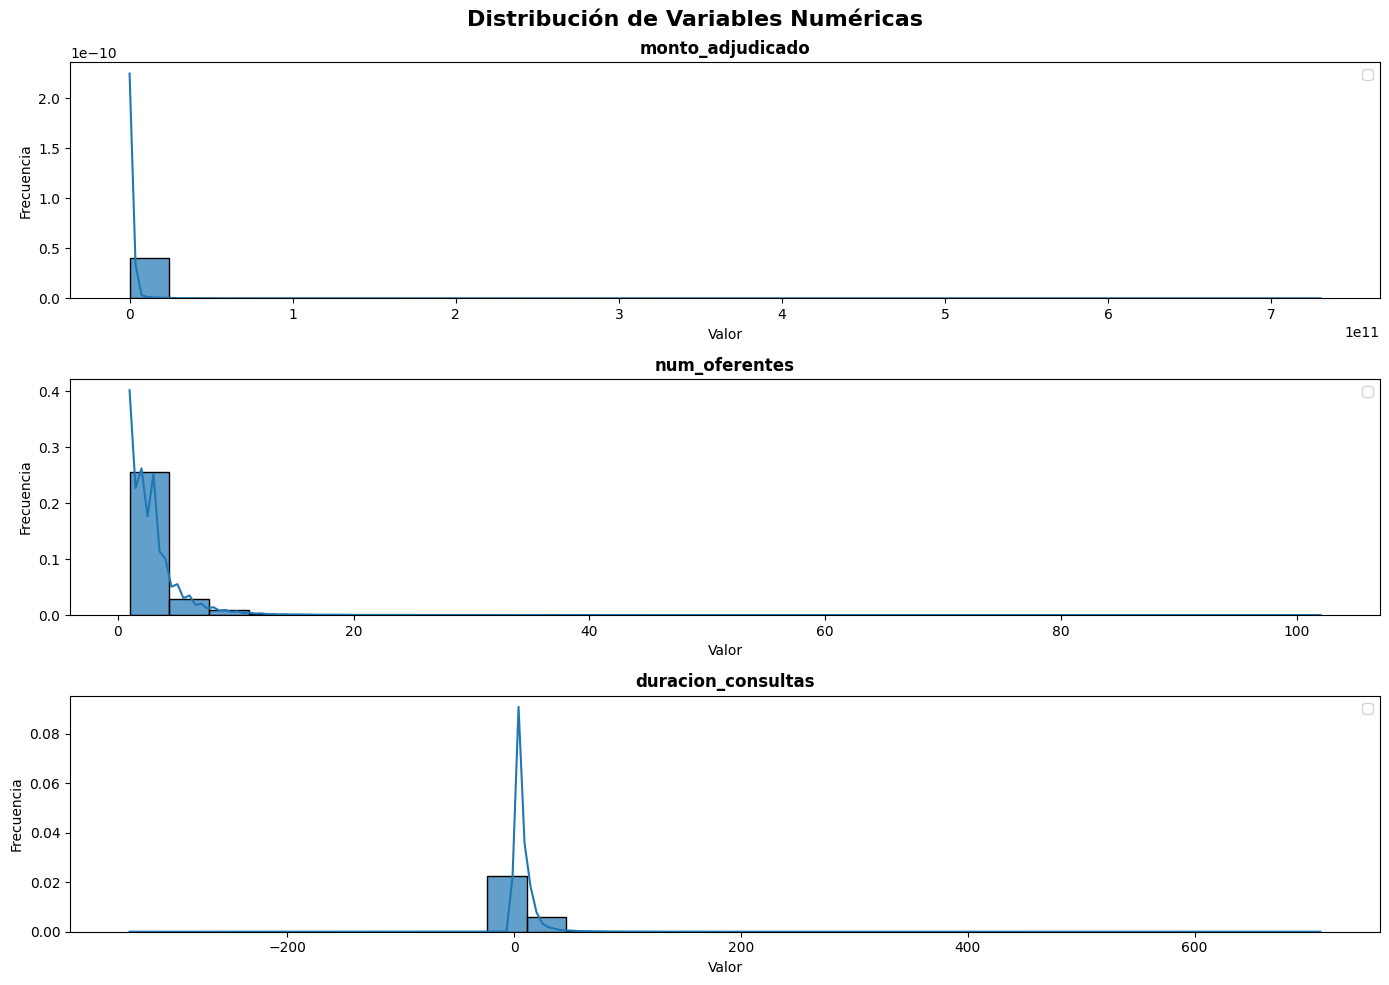

In [233]:
# Histogramas y boxplots para variables numéricas
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

for idx, var in enumerate(columnas_numericas):
    ax = axes[idx]

    # Histograma con curva normal
    sns.histplot(df[var].dropna(),
                bins=30,
                edgecolor='black',
                alpha=0.7,
                stat='density',
                kde=True,
                ax=ax)

    ax.set_title(f'{var}', fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.savefig('histogramas.png', dpi=300, bbox_inches='tight')
plt.show()



Comprobamos que el monto adjudicado cuenta con una alta asiemtria positiva, esto quiere decir que la mayoria de los contratos

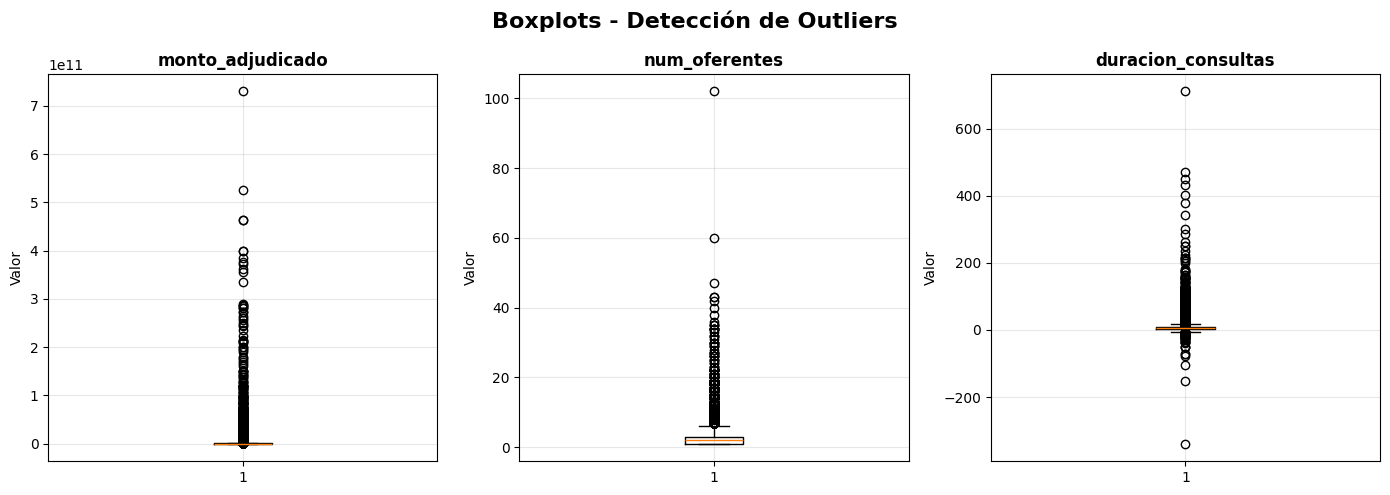

In [234]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Boxplots - Detección de Outliers', fontsize=16, fontweight='bold')

for idx, var in enumerate(columnas_numericas):
    axes[idx].boxplot(df[var].dropna())
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Tratamiento de importes extremos

Los importes muy altos no se eliminan automáticamente

La estrategia será:

1. Identificar los valores extremos.
2. Revisar si parecen errores o casos reales.
3. Usar transformación logarítmica para modelado de regresión.
4. Usar percentiles o winsorización solo como análisis de sensibilidad, no como borrado automático

In [235]:
percentiles_monto = df["monto_adjudicado"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999])
percentiles_monto

,monto_adjudicado
count,3.253100e+04
mean,1.552887e+09
std,1.288135e+10
min,0.000000e+00
25%,8.000000e+07
50%,1.490995e+08
75%,3.715395e+08
90%,1.200000e+09
95%,3.299891e+09
99%,2.706938e+10


In [236]:
columnas_revision_importes = [
    "id_llamado", "convocante", "categoria", "categoria_detallada", "modalidad",
    "tipo_procedimiento", "num_oferentes", "monto_adjudicado_original", "moneda_original",
    "monto_adjudicado", "monto_adjudicado_usd"
]

columnas_revision_importes = [c for c in columnas_revision_importes if c in df.columns]
df.sort_values("monto_adjudicado", ascending=False)[columnas_revision_importes].head(20)

,id_llamado,convocante,categoria,categoria_detallada,modalidad,tipo_procedimiento,num_oferentes,monto_adjudicado
41970,ocds-03ad3f-274148-1,Ministerio de Salud Pública y Bienestar Social...,goods,"Bienes - Equipos, Productos e instrumentales M...",Por Item,Licitación Pública Nacional,40.0,7.300645e+11
22909,ocds-03ad3f-285221-1,Ministerio de Salud Pública y Bienestar Social...,goods,"Bienes - Equipos, Productos e instrumentales M...",Por Item,Licitación Pública Nacional,43.0,5.266899e+11
35089,ocds-03ad3f-369095-1,Administración Nacional de Electricidad (ANDE),works,"Obras - Construcción, Restauración, Reconstruc...",Por Lote,Licitación Pública Nacional,12.0,4.627469e+11
11147,ocds-03ad3f-243118-1,Ministerio de Obras Públicas y Comunicaciones ...,works,"Obras - Construcción, Restauración, Reconstruc...",Por Lote,Licitación Pública Internacional,6.0,4.627000e+11
25966,ocds-03ad3f-260313-2,Ministerio de Obras Públicas y Comunicaciones ...,works,"Obras - Construcción, Restauración, Reconstruc...",Por Total,Licitación Pública Internacional,2.0,4.000000e+11
30743,ocds-03ad3f-246651-1,Ministerio de Obras Públicas y Comunicaciones ...,works,"Obras - Construcción, Restauración, Reconstruc...",Por Lote,Licitación Pública Nacional,13.0,4.000000e+11
22789,ocds-03ad3f-275540-1,Ministerio de Obras Públicas y Comunicaciones ...,works,"Obras - Construcción, Restauración, Reconstruc...",Por Total,Licitación Pública Internacional,6.0,3.841046e+11
40171,ocds-03ad3f-427649-1,Petróleos Paraguayos (PETROPAR),goods,Bienes - Combustibles y Lubricantes,Por Item,Contratación por Excepción,NaN,3.757969e+11
8618,ocds-03ad3f-347619-1,Instituto de Previsión Social (IPS),goods,"Bienes - Equipos, Productos e instrumentales M...",Por Item,Licitación Pública Nacional,38.0,3.728837e+11
21477,ocds-03ad3f-366710-1,Ministerio de Salud Pública y Bienestar Social...,works,"Obras - Construcción, Restauración, Reconstruc...",Por Total,Licitación Pública Internacional,NaN,3.625000e+11


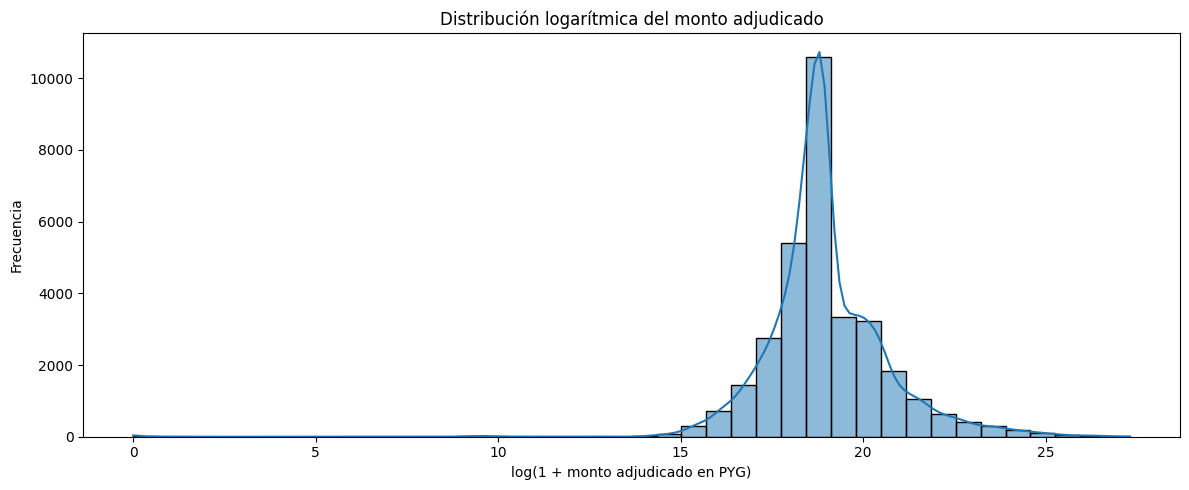

In [237]:
# asistido por IA: visualización logarítmica de los montos para reducir el efecto visual de valores extremos

df["log_monto_adjudicado"] = np.log1p(df["monto_adjudicado"].clip(lower=0))

plt.figure(figsize=(12, 5))
sns.histplot(df["log_monto_adjudicado"].dropna(), bins=40, kde=True)
plt.title("Distribución logarítmica del monto adjudicado")
plt.xlabel("log(1 + monto adjudicado en PYG)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [238]:

limite_p99_monto = df["monto_adjudicado"].quantile(0.99)
df["monto_adjudicado_winsor_p99"] = df["monto_adjudicado"].clip(upper=limite_p99_monto)

print(f"Límite p99 del monto adjudicado: {limite_p99_monto:,.2f}")
print("Nota: esta columna no reemplaza al monto original; solo sirve para comparar análisis con menor influencia de extremos.")

Límite p99 del monto adjudicado: 27,069,377,435.00
Nota: esta columna no reemplaza al monto original; solo sirve para comparar análisis con menor influencia de extremos.


convocante
Sin dato                                                  10665
Ministerio de Salud Pública y Bienestar Social (MSPBS)     1037
Ministerio de Obras Públicas y Comunicaciones (MOPC)        514
Municipalidad de Luque                                      477
Instituto de Previsión Social (IPS)                         366
Municipalidad de Fernando de la Mora                        305
Policia Nacional / Ministerio del Interior                  300
Municipalidad de Coronel Oviedo                             287
Administración Nacional de Electricidad (ANDE)              285
Comando en Jefe Uoc 1 / Ministerio de Defensa Nacional      277
Name: count, dtype: int64


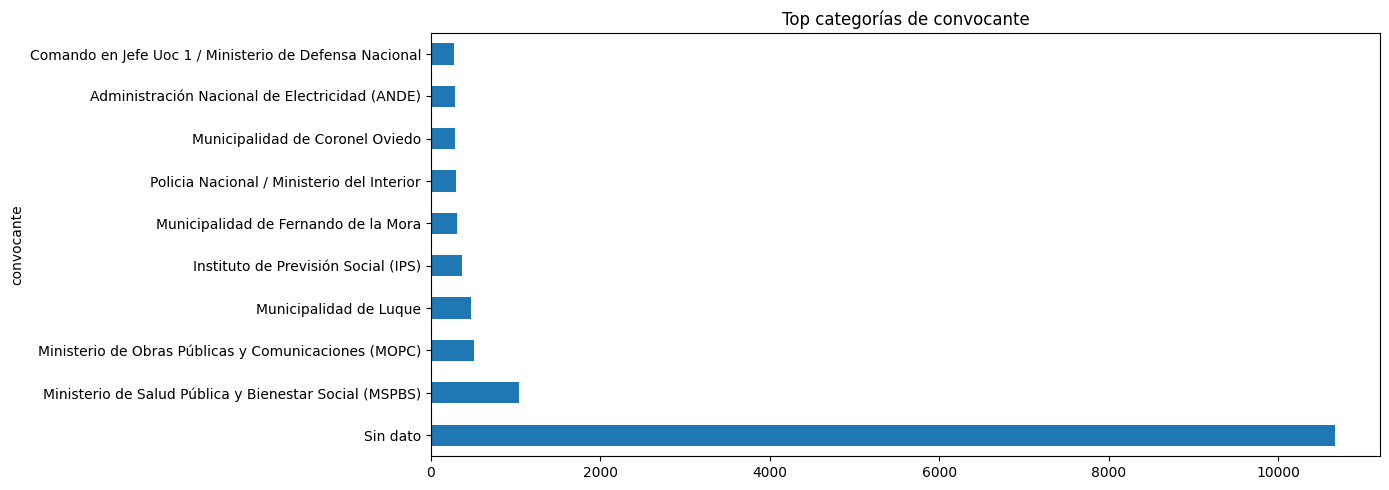

categoria
works       12981
goods       11149
Sin dato    10665
services     8658
Name: count, dtype: int64


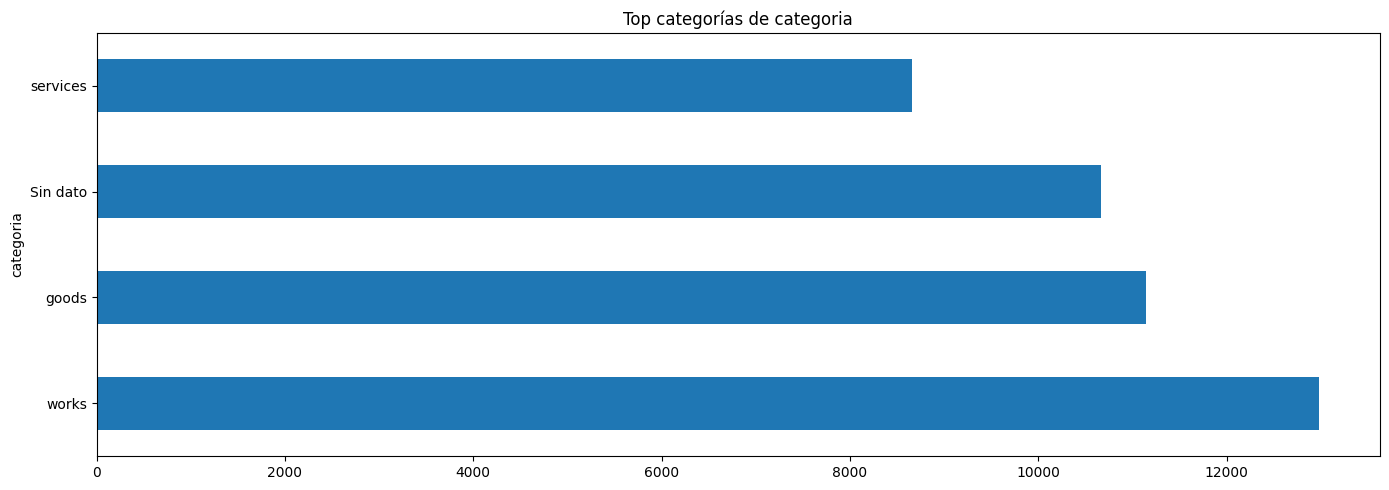

categoria_detallada
Obras - Construcción, Restauración, Reconstrucción o Remodelación y Reparación de Inmuebles                                              17531
Servicios - Servicios de Limpiezas, Mantenimientos y reparaciones menores y mayores de Instalaciones, Maquinarias y Vehículos             3532
Bienes - Equipos, accesorios y programas computacionales, de oficina, educativos, de imprenta, de comunicación y señalamiento             3401
Servicios - Servicios de ceremonial, gastronomico y funerarios                                                                            2773
Bienes - Materiales e insumos eléctricos, metálicos y no metálicos, Plásticos, cauchos. Repuestos, herramientas, cámaras y cubiertas.     1927
Bienes - Muebles y Enseres                                                                                                                1747
Servicios - Servicios Técnicos                                                                                            

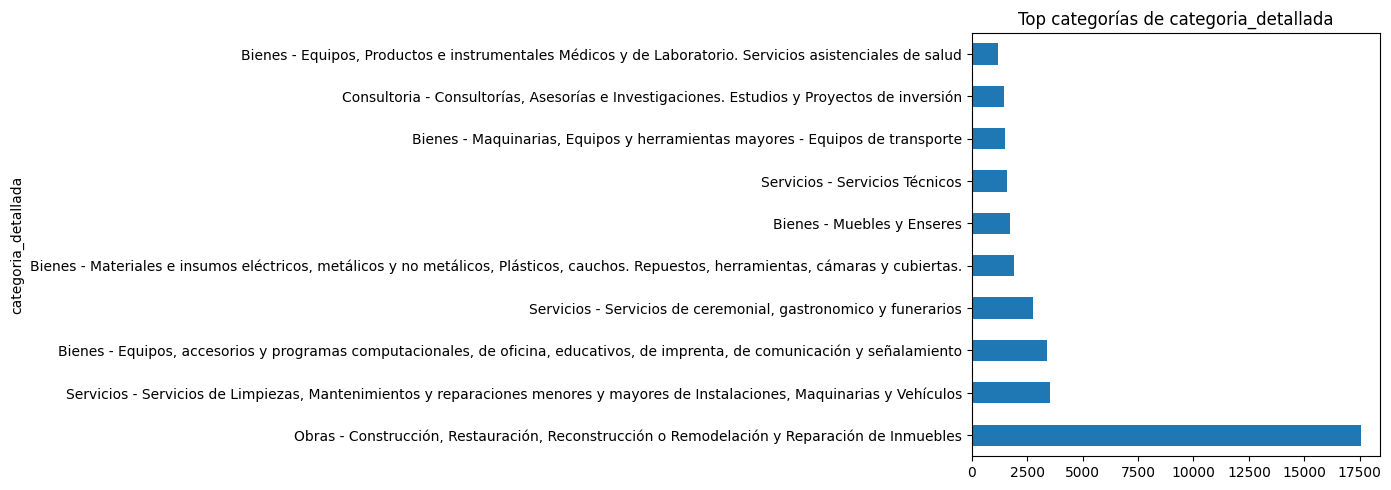

modalidad
Por Total    24503
Sin dato     10724
Por Item      4298
Por Lote      3893
Combinado       35
Name: count, dtype: int64


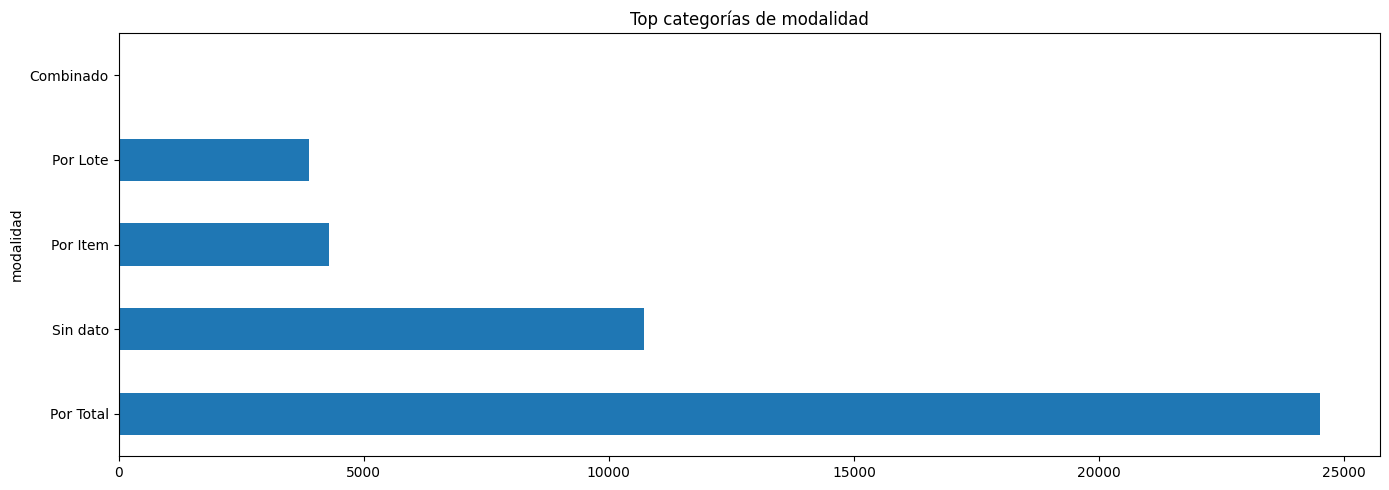

tipo_procedimiento
Contratación Directa                  19922
Sin dato                              10665
Concurso de Ofertas                    6909
Licitación Pública Nacional            3544
Contratación por Excepción             1331
Locación de Inmuebles                   565
Licitación Pública Internacional        116
BID - Concurso de Ofertas (CO/CP)        96
BID - Licitación Internacional           47
BID - Contratación Directa (CD/SD)       41
Name: count, dtype: int64


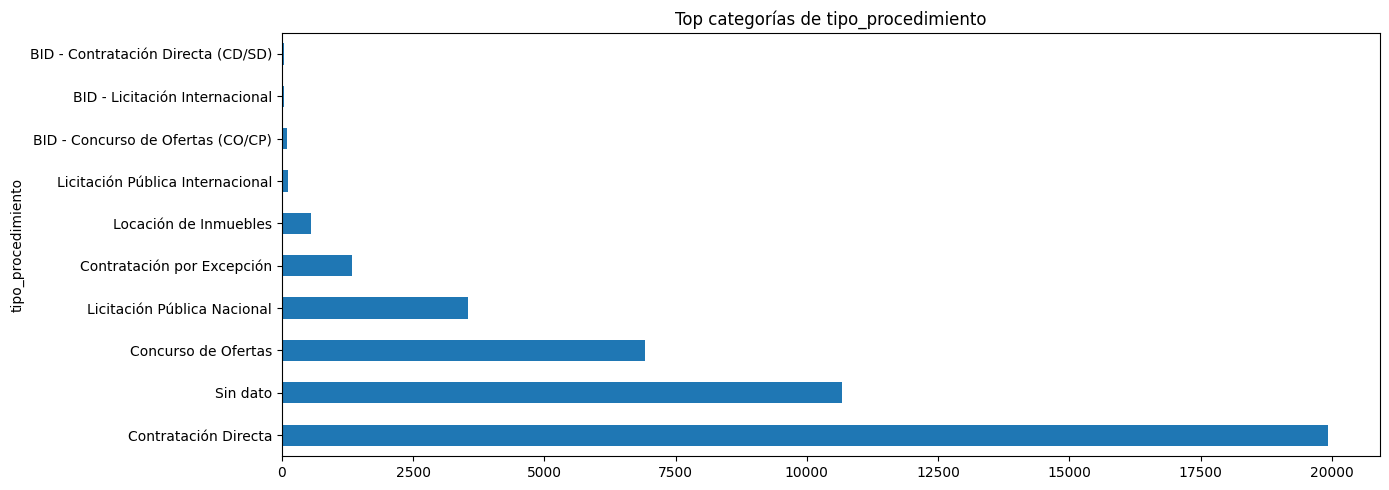

moneda
PYG         32729
Sin dato    10724
Name: count, dtype: int64


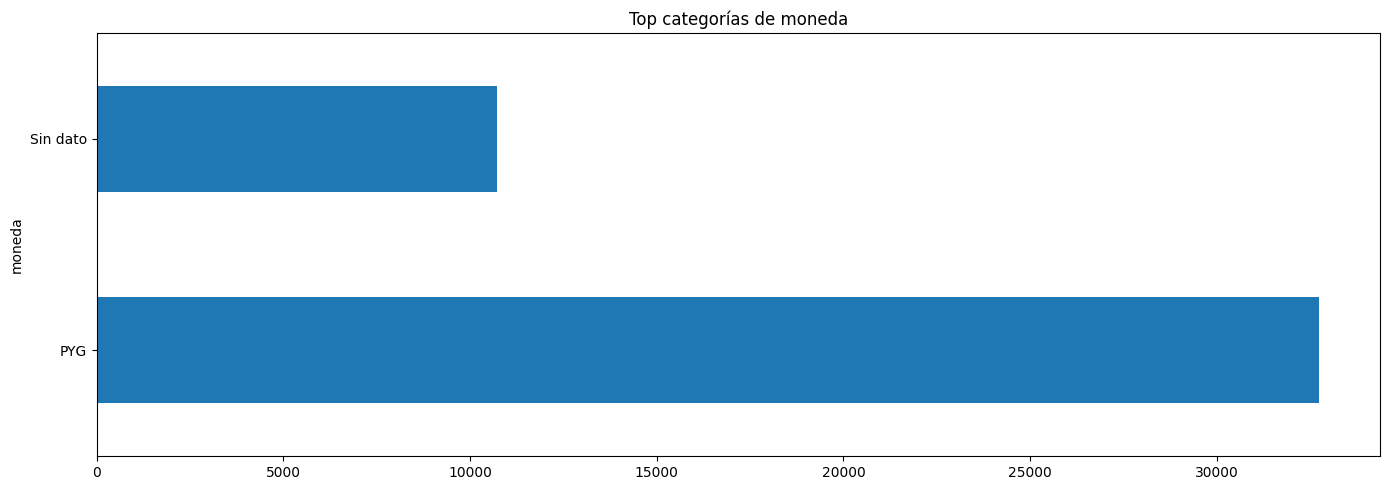

estado
complete        29945
planning        10600
cancelled        1358
unsuccessful     1276
active            202
Sin dato           72
Name: count, dtype: int64


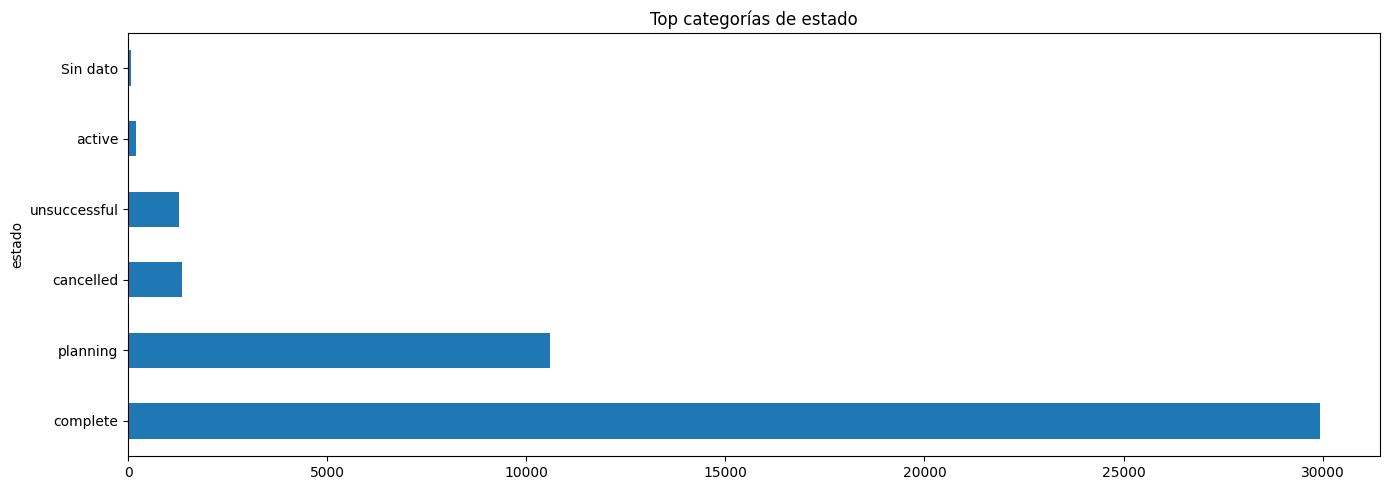

In [239]:
for col in columnas_categoricas:
    print(df[col].value_counts(dropna=False).head(10))
    plt.figure(figsize=(14, 5))
    df[col].value_counts(dropna=False).head(10).plot(kind='barh')
    plt.title(f'Top categorías de {col}')
    plt.tight_layout()
    plt.savefig(f'{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

##Analisis Bivariado


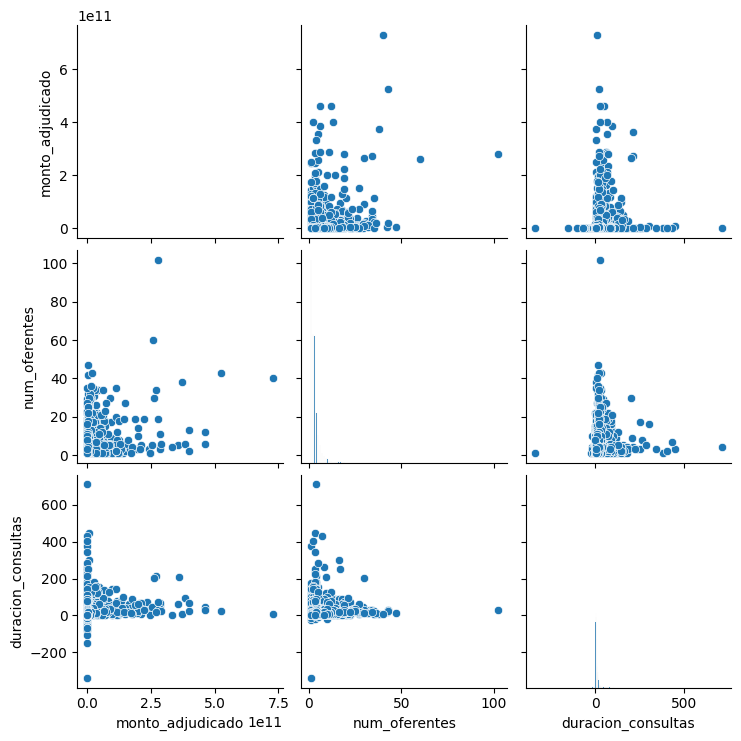

                    monto_adjudicado  num_oferentes  duracion_consultas
monto_adjudicado            1.000000       0.261974            0.191614
num_oferentes               0.261974       1.000000            0.150991
duracion_consultas          0.191614       0.150991            1.000000


In [240]:
#Correlacion entre variables numéricas
sns.pairplot(df[columnas_numericas])
plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print(df[columnas_numericas].corr())

No se observa ninguna correlacion lineal fuerte

In [241]:
# Monto adjudicado por convocante
print("\nMonto Adjudicado por convocante:")
print(df.groupby('convocante')['monto_adjudicado'].describe())


Monto Adjudicado por convocante:
                                                    count          mean  \
convocante                                                                
Administración Nacional de Electricidad (ANDE)      279.0  1.215290e+10   
Administración Nacional de Navegación y Puertos...   84.0  6.581564e+08   
Ag. Nac. de Eval. y Acreditación de la Educació...   35.0  4.127615e+08   
Agencia Financiera de Desarrollo (AFD)               86.0  3.099631e+08   
Agencia Nacional de Transito y Seguridad Vial (...   36.0  1.775825e+08   
...                                                   ...           ...   
Universidad Nacional de Misiones (UNAMIS)             4.0  2.678238e+08   
Universidad Nacional de Pilar (UNP)                  51.0  6.263133e+07   
Universidad Nacional de Villarrica del Espiritu...   45.0  2.523596e+08   
Universidad Politécnica Taiwán – Paraguay (UPTP)     28.0  2.488089e+08   
Vicepresidencia de la República (VP)                 34.0  9.44590

convocante
Ministerio de Obras Públicas y Comunicaciones (MOPC)    2.503374e+10
Administración Nacional de Electricidad (ANDE)          1.215290e+10
Instituto de Previsión Social (IPS)                     1.021216e+10
Petróleos Paraguayos (PETROPAR)                         8.538529e+09
Ministerio de Educación y Ciencias (MEC)                7.981977e+09
Name: monto_adjudicado, dtype: float64


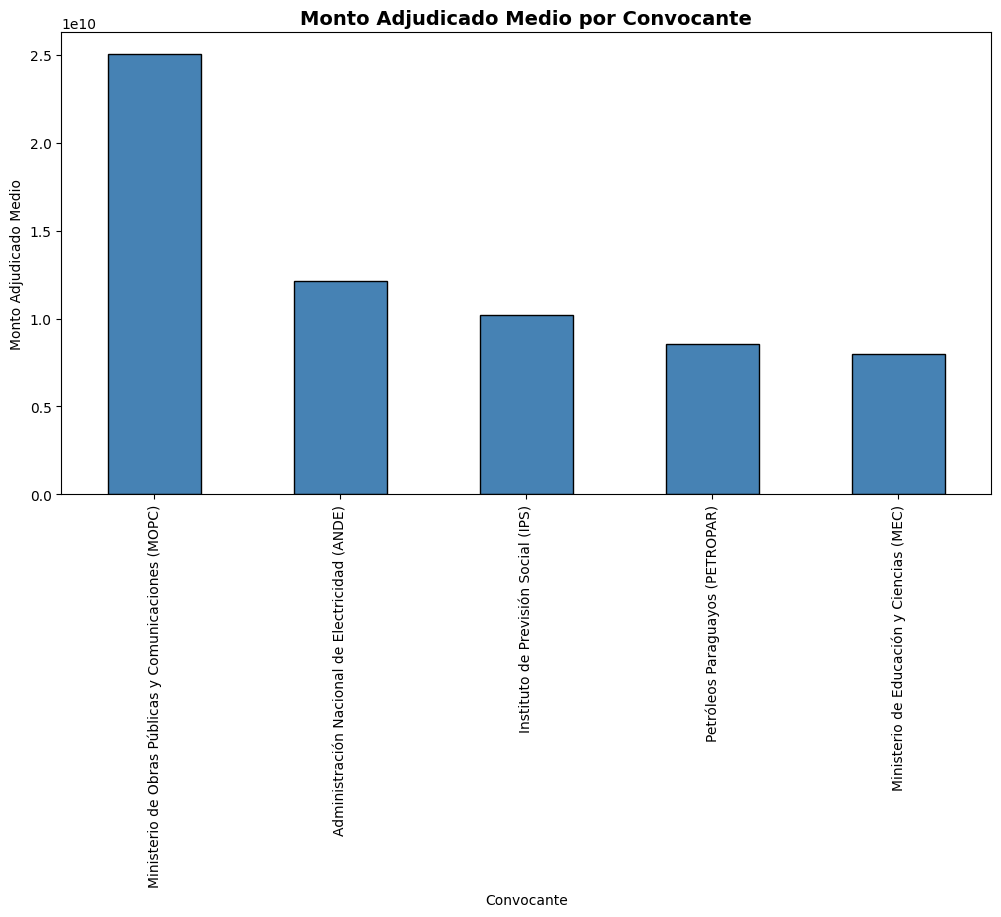

In [242]:
convocantes_monto_medio = df.groupby('convocante')['monto_adjudicado'].mean().sort_values(ascending=False).head(5)
print(convocantes_monto_medio)
plt.figure(figsize=(12, 6))
convocantes_monto_medio.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Monto Adjudicado Medio por Convocante', fontweight='bold', fontsize=14)
plt.xlabel('Convocante')
plt.ylabel('Monto Adjudicado Medio')

plt.savefig('monto_medio_por_convocante.png', dpi=300, bbox_inches='tight')
plt.show()

In [243]:

print("\nCategoria vs Modalidad:")
tabla_contingencia = pd.crosstab(df['categoria'], df['modalidad'])
print(tabla_contingencia)


Categoria vs Modalidad:
modalidad  Combinado  Por Item  Por Lote  Por Total  Sin dato
categoria                                                    
Sin dato           0         0         0          0     10665
goods             17      3778      1211       6133        10
services          18       464      1094       7034        48
works              0        56      1588      11336         1


           count          mean       median           std
categoria                                                
goods      11041  1.914999e+09  139991200.0  1.418429e+10
works      12976  1.565150e+09  141097160.5  1.487523e+10
services    8514  1.064607e+09  171833526.0  5.956115e+09
Sin dato       0           NaN          NaN           NaN


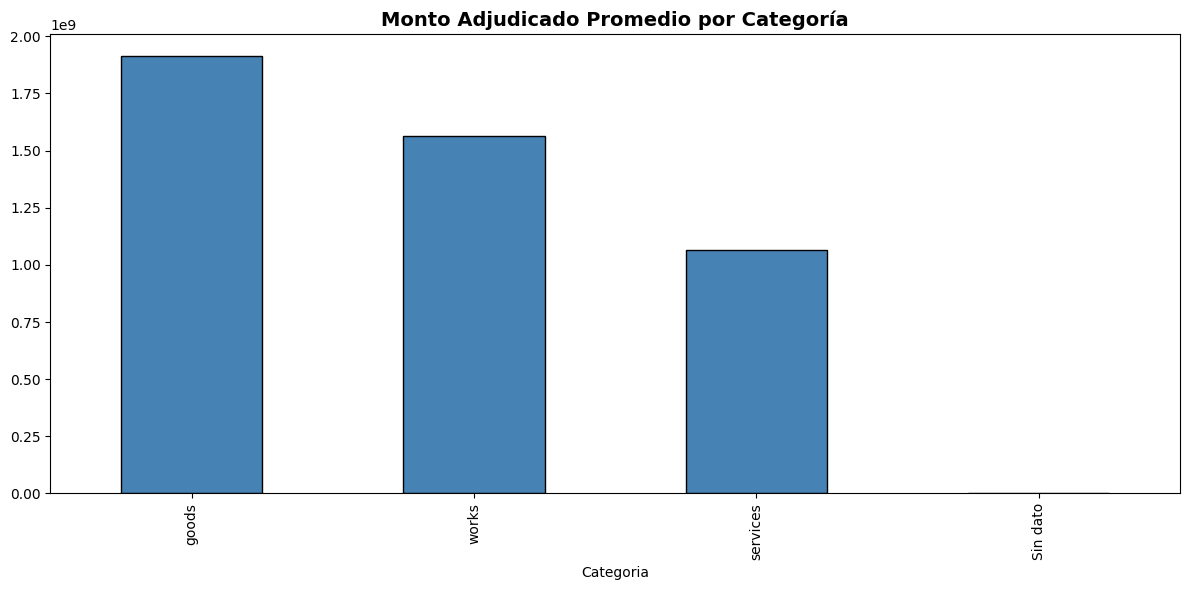

In [244]:
monto_por_cat = df.groupby('categoria')['monto_adjudicado'].agg(['count', 'mean', 'median', 'std'])
print(monto_por_cat.sort_values('mean', ascending=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
monto_por_cat['mean'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Monto Adjudicado Promedio por Categoría', fontweight='bold', fontsize=14)
ax.set_xlabel('Categoria')
plt.tight_layout()
plt.show()

<Axes: xlabel='fecha'>

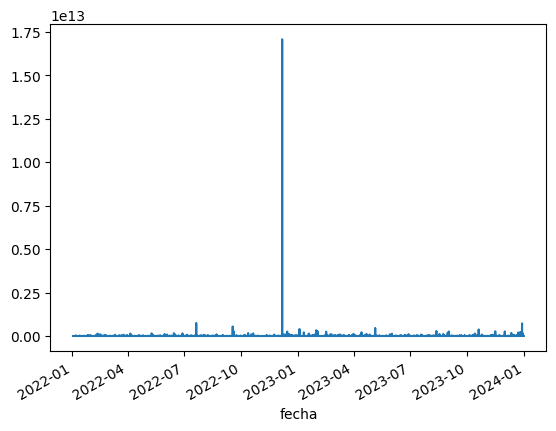

In [245]:
df.groupby('fecha')['monto_adjudicado'].sum().plot()

# 3. Clasificación Supervisada

Objetivo del modelo de clasificación: predecir si una adjudicación pertenece al grupo de monto alto o monto no alto.



monto_alto = 1  # Sí, es una adjudicación de monto alto

monto_alto = 0  # No, no es una adjudicación de monto alto



** clasificacion asistida con guias de ia


In [246]:
# importacion para modelos supervisados

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge,LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

In [247]:
# copia del df limpio
df_modelo = df_clean.copy()

# Calculamos el percentil 75 del monto adjudicado (se considera monto alto al 25% de las adjudicaciones con mayor monto)

umbral_monto_alto = df_modelo["monto_adjudicado"].quantile(0.75)

# variable objetivo para clasificación.
# Si el monto adjudicado es mayor o igual al percentil 75, asignamos 1, si no, asignamos 0.
df_modelo["monto_alto"] = np.where(
    df_modelo["monto_adjudicado"] >= umbral_monto_alto,
    1,
    0
)

# revision
df_modelo["monto_alto"].value_counts()

,count
monto_alto,
0,22296
1,7433


Calcula el valor que separa el 75% más bajo del 25% mas alto

In [248]:
df_modelo["monto_adjudicado"].quantile(0.75)

np.float64(369862250.0)

se seleccionan las columnas que el modelo predecirá a modo de detectar montos altos de adjudicacion

In [249]:
# se definen variables que se van a utilizar para intentar predecir si una adjudicación es de monto alto o no
# no se incluye monto_adjudicado
features_clasificacion = [
    "categoria",
    "categoria_detallada",
    "modalidad",
    "tipo_procedimiento",
    "num_oferentes",
    "duracion_consultas",
    "anio"
]

X = df_modelo[features_clasificacion]

# Definimos la variable objetivo, es lo que se intentará predecir
y = df_modelo["monto_alto"]

en este caso el modelo visualizará el comportamiento de cada campo

ejemplo ciertas categorias tienden a tener montos altos

a continuacion se separan valores numericos de textos

In [250]:
variables_texto =[
    "categoria",
    "categoria_detallada",
    "modalidad",
    "tipo_procedimiento"]

variables_numericas = [
    "num_oferentes",
    "duracion_consultas",
    "anio"]

entrenamiento y prueba test

In [251]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25, # 75% de los datos para entrenar y 25 para testeo
    random_state=42,
    stratify=y # con esta linea se busca que tanto el entrenamiento como la prueba se mantengan parecidos en cuanto a proporciones
)

# con split se divide el entrenamiento en train para que el modelo aprenda y test para la evaluacion

Procesamiento

In [252]:

#  en este caso se toma la decision de rellenar categorias nulas con las mas frecuentes
transformador_segmentos = Pipeline(steps=[
    ("rellenar_nulos", SimpleImputer(strategy="most_frequent")),
    ("codificar_categorias", OneHotEncoder(handle_unknown="ignore"))
])

#  Rellena nulos con la mediana
transformador_numerico = Pipeline(steps=[
    ("rellenar_nulos", SimpleImputer(strategy="median"))
])


# en las siguientes lineas se unen el procesamiento
preprocesamiento = ColumnTransformer(transformers=[
    ("cat", transformador_segmentos, variables_texto),
    ("num", transformador_numerico, variables_numericas)
])

Prueba de modelo

In [253]:
# Modelo de prueba para predecir siempre la clase mas frecuente
modelo_prueba = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", DummyClassifier(strategy="most_frequent")) #predice la clase mas frecuente
])

# se entrena el modelo base de prueba
modelo_prueba.fit(X_train, y_train)

# generacion de predicciones
y_pred_dummy = modelo_prueba.predict(X_test)

# evaluacion
print("Matriz de confusión - DummyClassifier")
print(confusion_matrix(y_test, y_pred_dummy))

print("\nReporte de clasificacion DummyClassifier")
print(classification_report(y_test, y_pred_dummy))

Matriz de confusión - DummyClassifier
[[5575    0]
 [1858    0]]

Reporte de clasificacion DummyClassifier
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      5575
           1       0.00      0.00      0.00      1858

    accuracy                           0.75      7433
   macro avg       0.38      0.50      0.43      7433
weighted avg       0.56      0.75      0.64      7433



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



RandomForest Classifier

Es un modelo de clasificacion basado en arboles de decision

In [254]:
# creacion de pipeline del modelo Random Forest
modelo_rf_clasificacion = Pipeline(steps=[ #arma una cadena
    ("preprocesamiento", preprocesamiento),
    ("modelo", RandomForestClassifier(
        n_estimators=100, # se usan 100 estimadores
        random_state=42,
        class_weight="balanced" #montos altos = 1 representan un 25%, con esta clase se da mas peso a esta minoria
    ))
])

# entrenamiento
modelo_rf_clasificacion.fit(X_train, y_train)

# prediccion de clases sobre el conjunto de prueba
y_pred_rf = modelo_rf_clasificacion.predict(X_test)

# prediccion de probabilidades
y_proba_rf = modelo_rf_clasificacion.predict_proba(X_test)[:, 1]

Evaluacion

precision: de todas las adjudicaciones que el modelo identifica como monto alto, cuantas realmente eran monto alto?

recall: de todas las adjudicaciones que realmente eran de monto alto, cuantas detectó el modelo?

f1score: esto combina precsion y recall

suport: cantidad real de casos

In [255]:
# Matriz de confusión
print("Matriz de confusión Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

# Reporte de clasificación
print("\nReporte de clasificación - Random Forest")
print(classification_report(y_test, y_pred_rf))

# medicion de que tan bien el modelo separa las clases 0 y 1
roc_auc = roc_auc_score(y_test, y_proba_rf)
print("\nROC AUC:", roc_auc)

Matriz de confusión Random Forest
[[4942  633]
 [ 243 1615]]

Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      5575
           1       0.72      0.87      0.79      1858

    accuracy                           0.88      7433
   macro avg       0.84      0.88      0.85      7433
weighted avg       0.89      0.88      0.89      7433


ROC AUC: 0.958112295877239


Interpretacion del modelo
0.50 es parecido a adivinar

0.60 - 0.70 es débil/moderado

0.70 - 0.80 es aceptable

0.80 - 0.90 es bueno

mayor a 0.90 es muy bueno

Matriz de confusion

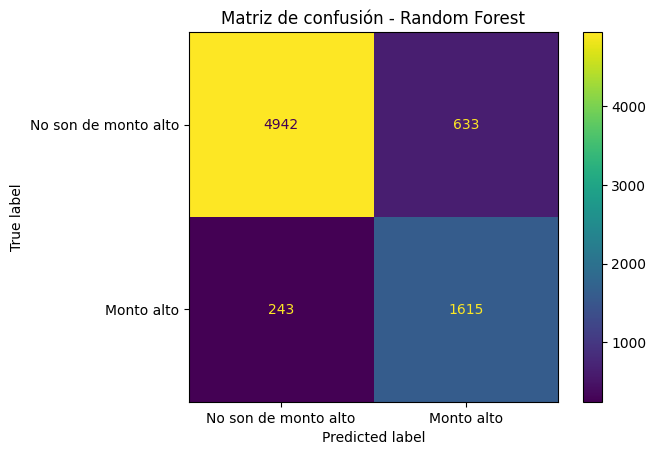

In [256]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No son de monto alto", "Monto alto"]
)

plt.title("Matriz de confusión - Random Forest")
plt.show()

Interpretacion

4942 no eran de monto alto y el modelo predijo que no eran de monto alto \
633 no eran de monto alto, pero el modelo predijo que eran de monto alto \
243 eran de monto alto pero el modelo predijo que no eran de monto alto \
1615 eran de monto alto y el modelo predijo que eran de monto alto


Acierto:
7433 casos totales
4942 + 1615 = 6557 / 7433 = 86,9%

# 4. Regresión Supervisada

Objetivo del modelo de regresion: predecir el monto adjudicado



In [257]:
#Hacemos una copia del df
df_regresion = df_clean.copy()
df_regresion.dropna(inplace=True)

#eliminamos los valores por encima del P97 por alta asimetría, para que no dominen los outliers

df_regresion = df_regresion[df_regresion['monto_adjudicado'] <= df_regresion['monto_adjudicado'].quantile(0.97)]

#Separamos X e y, tambien creamos una lista de las columnas categoricas y numericas
X = df_regresion.drop(['id_llamado','fecha','monto_adjudicado','moneda','estado','anio','mes','anio_mes'], axis=1)
y = df_regresion['monto_adjudicado']
num_cols = X.select_dtypes(include=['float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [258]:
# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [259]:
#Pipeline
#Utilizamos Power transformer para estabilizar la varianza y minimizar la asimetría
pt_y = PowerTransformer(method='yeo-johnson')
y_train_pt = pt_y.fit_transform(y_train.values.reshape(-1, 1)).ravel() #  Asistido con IA
y_test_pt = pt_y.transform(y_test.values.reshape(-1, 1)).ravel()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('power', PowerTransformer(method='yeo-johnson', standardize=True)),
        ]), num_cols),

        # One Hot Encoder para los catos categóricos
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [260]:
#Entrenamiento
model_pipeline.fit(X_train, y_train_pt)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['num_oferentes',
                                                   'duracion_consultas']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['convocante', 'categoria',
                                                   'categoria_detallada',
                                                   'modalidad',
                                                   'tipo_procedimiento'])])),
                ('regressor', LinearRegression())])

In [261]:
y_pred_train_pt = model_pipeline.predict(X_train)
y_pred_train_orig= pt_y.inverse_transform(y_pred_train_pt.reshape(-1, 1)).ravel() #Asistido con IA

y_pred_test_pt = model_pipeline.predict(X_test)
y_pred_test_orig = pt_y.inverse_transform(y_pred_test_pt.reshape(-1, 1)).ravel()

y_train_orig = pt_y.inverse_transform(y_train_pt.reshape(-1, 1)).ravel()
y_test_orig = pt_y.inverse_transform(y_test_pt.reshape(-1, 1)).ravel()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros



In [262]:
#Evaluacion
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
r2_test = r2_score(y_test_orig, y_pred_test_orig)

print(f"RMSE Test (original): {rmse_test:,.0f}")
print(f"R² Test (original): {r2_test:.3f}")

RMSE Test (original): 488,658,298
R² Test (original): 0.606


In [263]:
from xgboost import XGBRegressor
#modelo con XGBoost
model_pipeline_xgboost = Pipeline([('prep', preprocessor), ('xgb', XGBRegressor(n_estimators=200))])
model_pipeline_xgboost.fit(X_train, y_train_pt)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer())]),
                                                  ['num_oferentes',
                                                   'duracion_consultas']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['convocante', 'categoria',
                                                   'categoria_detallada',
                                                   'modalidad',
                                                   'tipo_procedimiento'])])),
                ('xgb',
                 XGBRegressor(base_score=None...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [264]:
y_pred_orig = pt_y.inverse_transform(model_pipeline_xgboost.predict(X_test).reshape(-1,1)).ravel()
print(f"NUEVO RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_orig)):,.0f}")
print(f"NUEVO R2: {r2_score(y_test, y_pred_orig):.3f}")

NUEVO RMSE: 446,363,663
NUEVO R2: 0.671


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [0, 2, 4] during transform. These unknown categories will be encoded as all zeros



# 5. Clustering
El objetivo es identificar perfiles de comportamiento entre las instituciones convocantes, para eso se utilizan las variables frecuencia de adjudicaciones y el monto promedio adjudicado

In [265]:
#Importamos las librerias a utilizar
from sklearn.cluster import KMeans
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [266]:
df_clustering = df_clean.copy().dropna()

perfiles_convocantes = df_clustering.groupby('convocante').agg(
    freq_adjudicaciones = ('monto_adjudicado', 'count'),
    monto_prom          = ('monto_adjudicado', 'mean')
).reset_index()

print(perfiles_convocantes.head())
print(perfiles_convocantes.describe())

                                          convocante  freq_adjudicaciones  \
0     Administración Nacional de Electricidad (ANDE)                  249   
1  Administración Nacional de Navegación y Puerto...                   72   
2  Ag. Nac. de Eval. y Acreditación de la Educaci...                   35   
3             Agencia Financiera de Desarrollo (AFD)                   73   
4  Agencia Nacional de Transito y Seguridad Vial ...                   28   

     monto_prom  
0  1.136594e+10  
1  5.759932e+08  
2  4.127615e+08  
3  3.208625e+08  
4  1.697061e+08  
       freq_adjudicaciones    monto_prom
count           453.000000  4.530000e+02
mean             55.693157  6.520668e+08
std              61.595568  1.798938e+09
min               1.000000  9.262727e+06
25%              17.000000  1.480263e+08
50%              43.000000  2.103734e+08
75%              72.000000  4.276677e+08
max             734.000000  2.788205e+10


In [267]:
X = perfiles_convocantes[['freq_adjudicaciones', 'monto_prom']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Eelgimos k en un rango entre 3 y 5 para realizar los perfiles y evaluamos. Una puntuación más alta del coeficiente de silhoutte se relaciona con un modelo con grupos mejor definidos.



In [268]:
#Asistido con IA
inertias = []
silhouettes = []
K_range = range(3, 6)  # simple: de 3 a 5 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print("Inertias:", inertias)
print("Silhouettes:", silhouettes)

k_optimo = K_range[int(np.argmax(silhouettes))]
print("K elegido (por silhouette):", k_optimo)

Inertias: [331.43846410679345, 262.0497193702605, 196.80104028228638]
Silhouettes: [np.float64(0.5989614404718001), np.float64(0.6006360258234394), np.float64(0.5930835111903299)]
K elegido (por silhouette): 4


##Modelos

In [269]:
#Funcion para visualizar los grupos
def visualizar_grupos(labels):
  df_plot_clusters = perfiles_convocantes.copy()
  df_plot_clusters['labels'] = labels.astype(str)

  fig = px.scatter(df_plot_clusters,
                   x='freq_adjudicaciones',
                   y='monto_prom',
                   color='labels',
                   labels={
                       'freq_adjudicaciones': 'Frecuencia de adjudicaciones',
                       'monto_prom': 'Monto Promedio'
                   })
  fig.update_layout(margin=dict(l=20,r=20,t=20,b=20),
                    paper_bgcolor="LightSteelBlue",
                    width=400)
  return fig.show()

###K means


In [270]:
k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

In [271]:
visualizar_grupos(labels_kmeans)

###Mini Batch K-means

In [272]:
from sklearn.cluster import MiniBatchKMeans
mb= MiniBatchKMeans(n_clusters=k_optimo, init='k-means++',n_init='auto',random_state=0,batch_size=1000)
labels_mbkmeans=mb.fit_predict(X_scaled)

In [273]:
visualizar_grupos(labels_mbkmeans)

###DBScan

In [274]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.30,min_samples=10)
labels_dbscan= db.fit_predict(X_scaled)

In [275]:
visualizar_grupos(labels_dbscan)

###BIRCH

In [276]:
from sklearn.cluster import Birch
model = Birch(n_clusters=k_optimo)
labels_birch = model.fit_predict(X_scaled)

In [277]:
visualizar_grupos(labels_birch)

###Agglomerative Clustering

In [278]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=k_optimo)
labels_ac = agg.fit_predict(X_scaled)

In [279]:
visualizar_grupos(labels_ac)

##Evaluacion de los modelos

In [280]:
s_kmeans = metrics.silhouette_score(X_scaled, labels_kmeans, metric='euclidean')
s_mbkmeans = metrics.silhouette_score(X_scaled, labels_mbkmeans, metric='euclidean')
s_dbscan = metrics.silhouette_score(X_scaled, labels_dbscan, metric='euclidean')
s_birch = metrics.silhouette_score(X_scaled, labels_birch, metric='euclidean')
s_agglomerative_clustering = metrics.silhouette_score(X_scaled, labels_ac, metric='euclidean')

In [281]:
# Imprimir las métricas
print(f'Silhouette Score (K-Means): {s_kmeans}')
print(f'Silhouette Score (Mini-Batch K-Means): {s_mbkmeans}')
print(f'Silhouette Score (DBSCAN): {s_dbscan}')
print(f'Silhouette Score (BIRCH): {s_birch}')
print(f'Silhouette Score (Agglomerative Clustering): {s_agglomerative_clustering}')

Silhouette Score (K-Means): 0.6006360258234394
Silhouette Score (Mini-Batch K-Means): 0.39867778702047674
Silhouette Score (DBSCAN): 0.3633157898598793
Silhouette Score (BIRCH): 0.861762294702628
Silhouette Score (Agglomerative Clustering): 0.6437471715814838


El modelo que cuenta con grupos mejores definidos es BIRCH

In [282]:
perfiles_convocantes['cluster'] = labels_birch
resumen = perfiles_convocantes.groupby('cluster')[['freq_adjudicaciones', 'monto_prom']].mean().round(0)
resumen['n_inst'] = perfiles_convocantes.groupby('cluster').size()
print(resumen)

         freq_adjudicaciones    monto_prom  n_inst
cluster                                           
0                       53.0  5.211412e+08     449
1                      224.0  1.315992e+10       2
2                      734.0  7.191933e+09       1
3                      397.0  2.788205e+10       1
